In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller

In [2]:
data = pd.read_csv('Data/preprocessed/stacked_lmp_da_hr_data.csv')
data.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
data = data[['begin_time', 'NP-15 LMP']]
data['begin_time']=pd.to_datetime(data['begin_time'])
data

,begin_time,NP-15 LMP
0,2020-01-01 00:00:00,32.76137
1,2020-01-01 01:00:00,30.90384
2,2020-01-01 02:00:00,32.15974
3,2020-01-01 03:00:00,31.24182
4,2020-01-01 04:00:00,30.98365
...,...,...
42091,2024-12-31 19:00:00,52.95726
42092,2024-12-31 20:00:00,52.41941
42093,2024-12-31 21:00:00,52.23158
42094,2024-12-31 22:00:00,51.55114


In [3]:
data.groupby(data['begin_time']).count().value_counts()

NP-15 LMP
1            42086
2                5
Name: count, dtype: int64

There are 5 times with two prices - this is likely when clocks fall back every year. Let us check for missing values.

In [4]:
data.isna().value_counts()

begin_time  NP-15 LMP
False       False        42096
Name: count, dtype: int64

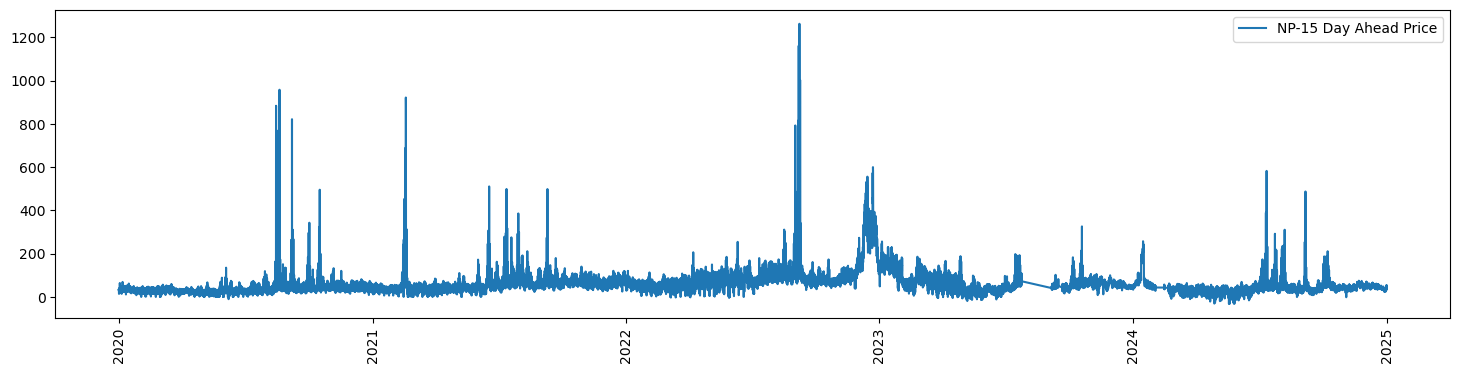

In [5]:
plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP'] , label='NP-15 Day Ahead Price')
plt.xticks(rotation=90)
plt.legend()
plt.show()

The figure indicates prices for some time points are missing in the second half of 2023. We compare the total number of time points we expect against the number available.

In [6]:
print(f'{len(pd.date_range(start=data['begin_time'].min(), end=data['begin_time'].max(), freq='1h'))}')
print(f"{len(data)}")

43848
42096


Clearly there are missing times. We fill in the values of missing times and take the average price where there are two prices for the same time.

In [7]:
# Remove duplicate times by replacing with mean value and insert missing times

def process_begin_times(df):
    df['begin_time'] = pd.to_datetime(df['begin_time'])
    df.set_index('begin_time', inplace=True)
    df = df.groupby(df.index).mean()
    dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1h')
    df = df.reindex(dates)
    df.reset_index(inplace=True)
    df.rename(columns={'index':'begin_time'}, inplace=True)
    return df 

In [8]:
data= process_begin_times(data)
data

,begin_time,NP-15 LMP
0,2020-01-01 00:00:00,32.76137
1,2020-01-01 01:00:00,30.90384
2,2020-01-01 02:00:00,32.15974
3,2020-01-01 03:00:00,31.24182
4,2020-01-01 04:00:00,30.98365
...,...,...
43843,2024-12-31 19:00:00,52.95726
43844,2024-12-31 20:00:00,52.41941
43845,2024-12-31 21:00:00,52.23158
43846,2024-12-31 22:00:00,51.55114


There is no obvious trend or seasonality in the data at this scale. If we zoom in on a day to day scale,

In [9]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

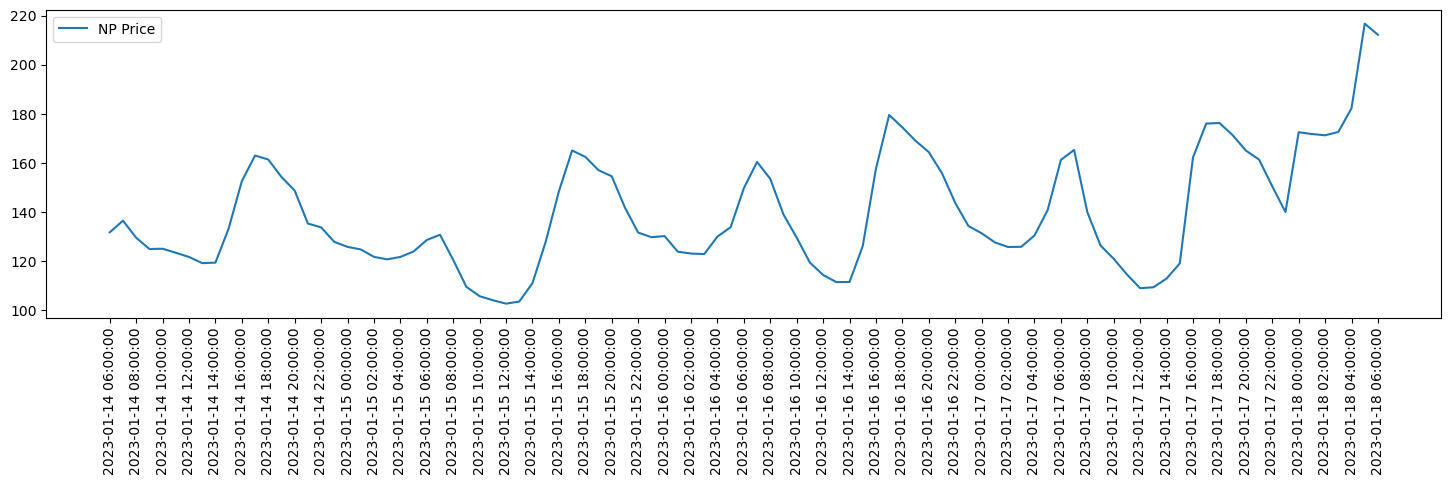

In [10]:
time1 = datetime.datetime(2023, 1, 14, 6, 0, 0)
time2 = datetime.datetime(2023, 1, 18, 6, 0, 0)

filtered_data = data[filter_times(data, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP'] , label='NP Price')


plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='2h'), labels=pd.date_range(start=time1, end=time2, freq='2h'), rotation=90)
plt.legend()
plt.show()

We notice that there are peaks in the morning and evening, and it is also reasonable to expect a seasonality of 24hrs in the prices. Let us try differencing by 24 hrs (this is where it is important to fill in the missing times so that we get correct differences).

In [11]:
data['NP-15 LMP 24hrdiffs'] = data['NP-15 LMP'] - data['NP-15 LMP'].shift(24)
data['NP-15 LMP Prev_day_price'] = data['NP-15 LMP'].shift(24)

Let us look at the same two plots for the differenced series.

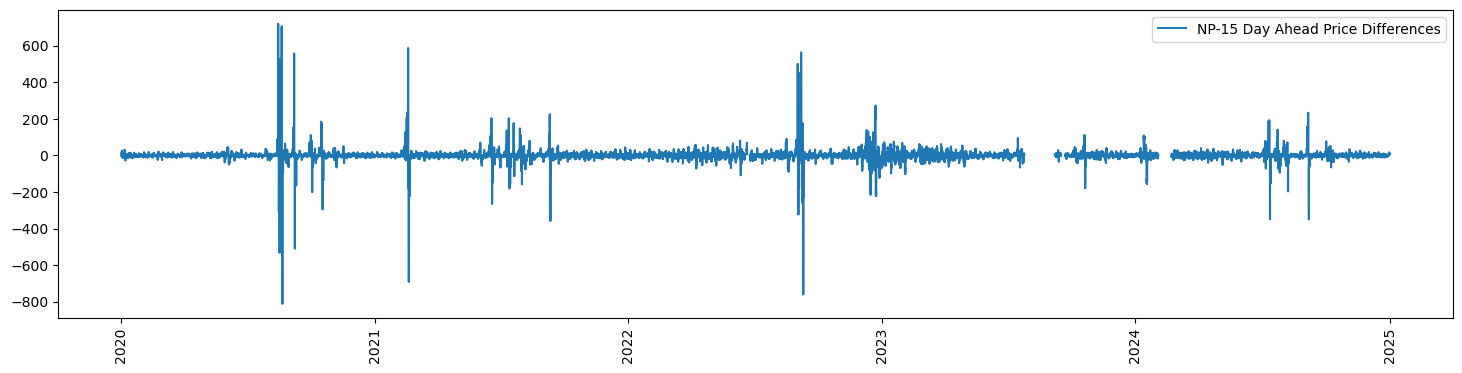

In [83]:
plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP 24hrdiffs'] , label='NP-15 Day Ahead Price Differences')
plt.xticks(rotation=90)
plt.legend()
plt.show()

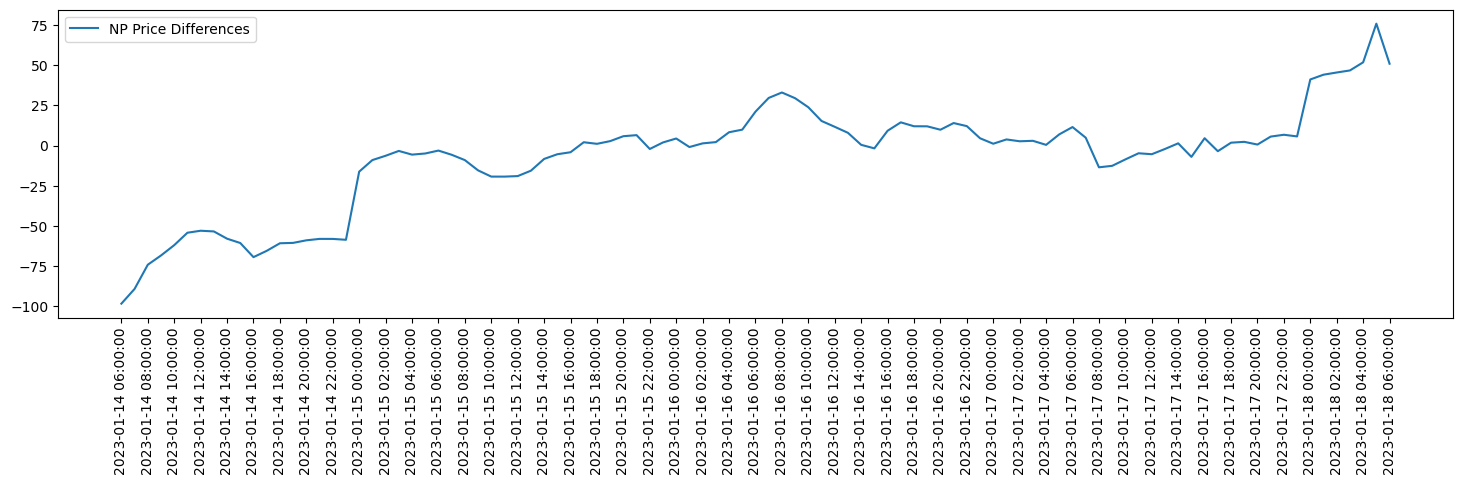

In [89]:
time1 = datetime.datetime(2023, 1, 14, 6, 0, 0)
time2 = datetime.datetime(2023, 1, 18, 6, 0, 0)

filtered_data = data[filter_times(data, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP 24hrdiffs'] , label='NP Price Differences')


plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='2h'), labels=pd.date_range(start=time1, end=time2, freq='2h'), rotation=90)
plt.legend()
plt.show()

There seems to be a trend, but not really if we look at a bigger time interval.

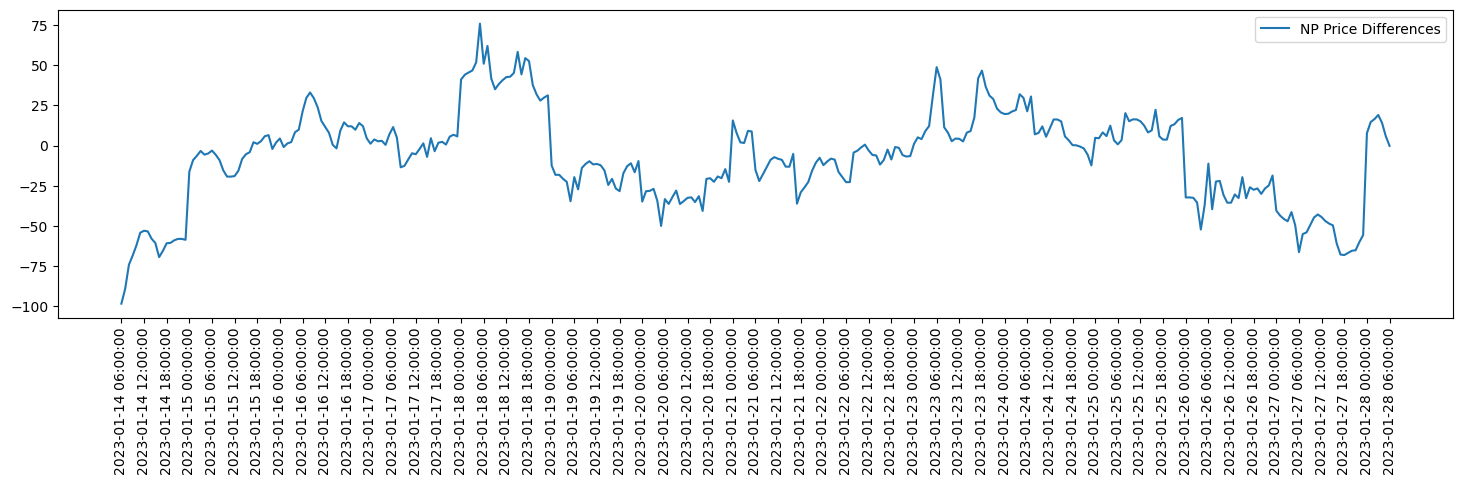

In [87]:
time1 = datetime.datetime(2023, 1, 14, 6, 0, 0)
time2 = datetime.datetime(2023, 1, 28, 6, 0, 0)

filtered_data = data[filter_times(data, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP 24hrdiffs'] , label='NP Price Differences')


plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='6h'), labels=pd.date_range(start=time1, end=time2, freq='6h'), rotation=90)
plt.legend()
plt.show()

Now we can check for stationarity.

In [ ]:

result = adfuller(data['NP-15 LMP 24hrdiffs'].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -27.589367261204128
p-value: 0.0
Critical Values:
   1%: -3.4305065608173915
   5%: -2.8616091963655443
   10%: -2.566806830989146


Let us make ACF and PACF plots

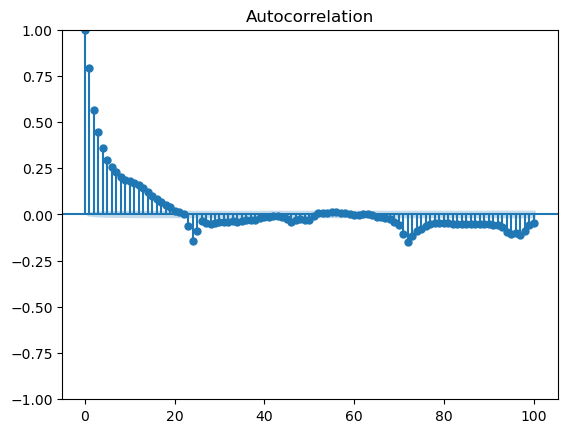

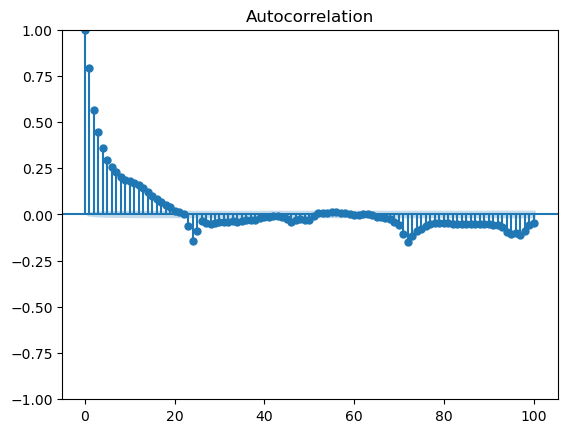

In [93]:
statsmodels.graphics.tsaplots.plot_acf(data['NP-15 LMP 24hrdiffs'].dropna(), lags=100)

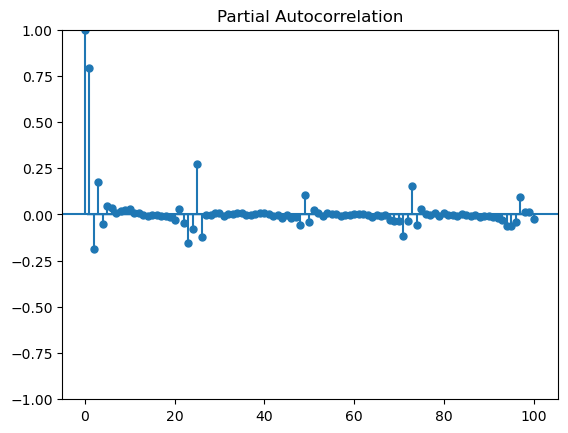

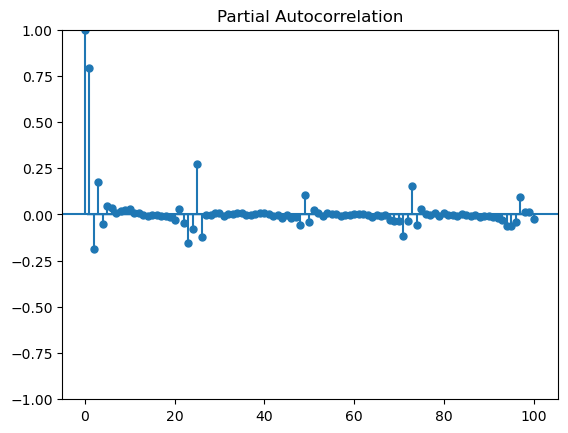

In [94]:
statsmodels.graphics.tsaplots.plot_pacf(data['NP-15 LMP 24hrdiffs'].dropna(), lags=100)

We shall now fit a SARIMA model to the time series. Based on the 24 hour differencing and the ACF and PACF peaks at intervals of 24, we expect a seasonal AR and MA component of order 1. The initial peaks also suggest non seasonal AR and MA components of small orders.

In [12]:
data.to_csv('Data/preprocessed/NP15_da_series.csv', index=False)